# EN | CREDIT CARD TRANSACTION FRAUD DETECTION
# ES | DETECCIÓN DE FRAUDE EN TRANSACCIONES CON TARJETA DE CRÉDITO

**EN | DATASET:** [CreditCardData](https://www.kaggle.com/datasets/anurag629/credit-card-fraud-transaction-data)

**EN | OBJECTIVE:** Create a machine learning model that can classify, in the best possible way, whether a transaction is fraudulent or not.

---

**ES | DATASET:** [CreditCardData](https://www.kaggle.com/datasets/anurag629/credit-card-fraud-transaction-data)

**ES | OBJETIVO:** Crear un modelo de machine learning que pueda clasificar, de la mejor manera posible, si una transacción es fraudulenta o no.

In [1]:
pip install pandas seaborn numpy matplotlib scikit-learn scipy imbalanced-learn openpyxl


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## EN | Libraries / ES | Librerías

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree as treeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn import metrics
import scipy.stats as stats
from sklearn.metrics import confusion_matrix

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import cross_val_score, KFold



## EN | Loading the Original Dataset / ES | Carga del Dataset Original

In [3]:
df= pd.read_excel('data/CreditCardData.xlsx')
df.head()

,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,#3577 209,2020-10-14,Wednesday,19,Visa,Tap,£5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,#3039 221,2020-10-14,Wednesday,17,MasterCard,PIN,£288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,#2694 780,2020-10-14,Wednesday,14,Visa,Tap,£5,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,#2640 960,2020-10-13,Tuesday,14,Visa,Tap,£28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,#2771 031,2020-10-13,Tuesday,23,Visa,CVC,£91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


## EN | Data Cleaning / ES | Limpieza de Datos

In [4]:
# Check for missing values and drop them
df.isna().sum()

Transaction ID             0
Date                       0
Day of Week                0
Time                       0
Type of Card               0
Entry Mode                 0
Amount                     6
Type of Transaction        0
Merchant Group            10
Country of Transaction     0
Shipping Address           5
Country of Residence       0
Gender                     4
Age                        0
Bank                       0
Fraud                      0
dtype: int64

In [5]:
# I decided to remove the NaNs since they are very few and it will not affect the results if removed.

df = df.dropna()
print(df.isna().sum())

Transaction ID            0
Date                      0
Day of Week               0
Time                      0
Type of Card              0
Entry Mode                0
Amount                    0
Type of Transaction       0
Merchant Group            0
Country of Transaction    0
Shipping Address          0
Country of Residence      0
Gender                    0
Age                       0
Bank                      0
Fraud                     0
dtype: int64


In [6]:
# Confirm that there are no remaining nulls

print(df.isnull().sum())

Transaction ID            0
Date                      0
Day of Week               0
Time                      0
Type of Card              0
Entry Mode                0
Amount                    0
Type of Transaction       0
Merchant Group            0
Country of Transaction    0
Shipping Address          0
Country of Residence      0
Gender                    0
Age                       0
Bank                      0
Fraud                     0
dtype: int64


In [7]:
# Verify column data types
df.info()

<class 'pandas.DataFrame'>
Index: 99977 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Transaction ID          99977 non-null  str           
 1   Date                    99977 non-null  datetime64[us]
 2   Day of Week             99977 non-null  str           
 3   Time                    99977 non-null  int64         
 4   Type of Card            99977 non-null  str           
 5   Entry Mode              99977 non-null  str           
 6   Amount                  99977 non-null  str           
 7   Type of Transaction     99977 non-null  str           
 8   Merchant Group          99977 non-null  str           
 9   Country of Transaction  99977 non-null  str           
 10  Shipping Address        99977 non-null  str           
 11  Country of Residence    99977 non-null  str           
 12  Gender                  99977 non-null  str           
 13  Ag

In [8]:
# Inspect unique values per column

# Define columns to process
columnas = df.columns

# Loop through each column to list unique values and counts
for columna in columnas:
    valores_unicos = df[columna].unique()
    conteo_valores = df[columna].value_counts()

    print(f"Unique values '{columna}':")
    print(valores_unicos)

    print(f"Count of unique values '{columna}':")
    print(conteo_valores)

    print("\n")

Unique values 'Transaction ID':
<StringArray>
['#3577 209', '#3039 221', '#2694 780', '#2640 960', '#2771 031', '#3446 698',
 '#3652 191', '#3161 927', '#3025 809', '#3413 696',
 ...
 '#2548 236', '#3024 504', '#3252 696', '#3396 111', '#2816 417', '#2960 683',
 '#3203 892', '#3304 849', '#3532 129', '#3107 092']
Length: 95657, dtype: str
Count of unique values 'Transaction ID':
Transaction ID
#2547 017    5
#2617 708    4
#3322 751    3
#3110 310    3
#3321 338    3
            ..
#2960 683    1
#3203 892    1
#3304 849    1
#3532 129    1
#3107 092    1
Name: count, Length: 95657, dtype: int64


Unique values 'Date':
<DatetimeArray>
['2020-10-14 00:00:00', '2020-10-13 00:00:00', '2020-10-16 00:00:00',
 '2020-10-15 00:00:00']
Length: 4, dtype: datetime64[us]
Count of unique values 'Date':
Date
2020-10-14    50173
2020-10-13    49802
2020-10-16        1
2020-10-15        1
Name: count, dtype: int64


Unique values 'Day of Week':
<StringArray>
['Wednesday', 'Tuesday', 'Thursday', 'Frida

In [9]:
# Remove typo in the BANK column
# Correct duplicate bank entries (“Barclays” vs. “Barlcays”)

df['Bank'] = df['Bank'].str.replace('Barlcays', 'Barclays')

In [10]:
# Strip the pound sterling symbol

df['Amount'] = df['Amount'].str.replace('£', '')

In [11]:
# Drop records for Thursday and Friday (only 26 rows total)

print(df['Day of Week'].value_counts())

df_fraud = df[df['Fraud'] == True]
h = df_fraud.groupby('Day of Week')['Fraud'].count()
print(h)

Day of Week
Wednesday    50166
Tuesday      49785
Friday          14
Thursday        12
Name: count, dtype: int64
Day of Week
Friday          1
Thursday        2
Tuesday      3731
Wednesday    3458
Name: Fraud, dtype: int64


In [12]:
# Remove fraud cases on Thursday and Friday (just 3 entries)
df = df[(df['Day of Week'] == 'Tuesday') | (df['Day of Week'] == 'Wednesday')]

In [13]:
# Cast each column to its proper data type

df = df.astype({'Shipping Address':'category',
        'Country of Residence': 'category',
        'Gender': 'category',
        'Bank':  'category',
        'Fraud': 'bool',
        'Country of Transaction' : 'category',
        'Merchant Group' : 'category',
        'Type of Transaction': 'category',
        'Amount' : 'int',
        'Entry Mode': 'category',
        'Type of Card': 'category',
        'Time': 'int',
        'Day of Week': 'category'
        })

df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.DataFrame'>
Index: 99951 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Transaction ID          99951 non-null  str           
 1   Date                    99951 non-null  datetime64[us]
 2   Day of Week             99951 non-null  category      
 3   Time                    99951 non-null  int64         
 4   Type of Card            99951 non-null  category      
 5   Entry Mode              99951 non-null  category      
 6   Amount                  99951 non-null  int64         
 7   Type of Transaction     99951 non-null  category      
 8   Merchant Group          99951 non-null  category      
 9   Country of Transaction  99951 non-null  category      
 10  Shipping Address        99951 non-null  category      
 11  Country of Residence    99951 non-null  category      
 12  Gender                  99951 non-null  category      
 13  Ag

In [14]:
# Notice the class imbalance
# There are far more non-fraud cases than fraud cases

print(df['Fraud'].value_counts())

Fraud
False    92762
True      7189
Name: count, dtype: int64


/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/2757410064.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x= df['Fraud'], palette = "Set1", edgecolor = "black", legend = False)


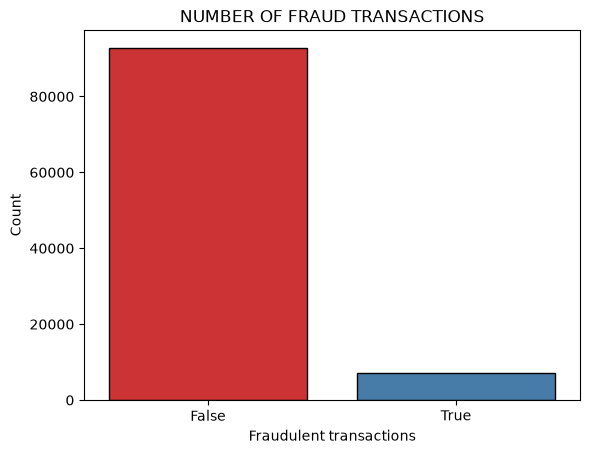

In [15]:
ax = sns.countplot(x= df['Fraud'], palette = "Set1", edgecolor = "black", legend = False)
ax.set_title('NUMBER OF FRAUD TRANSACTIONS')
ax.set(xlabel = 'Fraudulent transactions')
ax.set(ylabel='Count')
plt.show()

# EN | Data Exploration / ES | Exploración de Datos

In [16]:
# Calculate central tendency metrics

df.describe()

,Date,Time,Amount,Age
count,99951,99951.000000,99951.000000,99951.000000
mean,2020-10-13 12:02:44.672689,14.563776,112.576212,44.994199
min,2020-10-13 00:00:00,0.000000,5.000000,15.000000
25%,2020-10-13 00:00:00,10.000000,17.000000,38.200000
50%,2020-10-14 00:00:00,15.000000,30.000000,44.900000
75%,2020-10-14 00:00:00,19.000000,208.000000,51.700000
max,2020-10-14 00:00:00,24.000000,400.000000,86.100000
std,NaN,5.308407,123.438543,9.948101


In [17]:
# Identify the busiest transaction day

df['Day of Week'].value_counts()

Day of Week
Wednesday    50166
Tuesday      49785
Name: count, dtype: int64

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/1007227218.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = df['Day of Week'],palette = "Set1", edgecolor = "black")


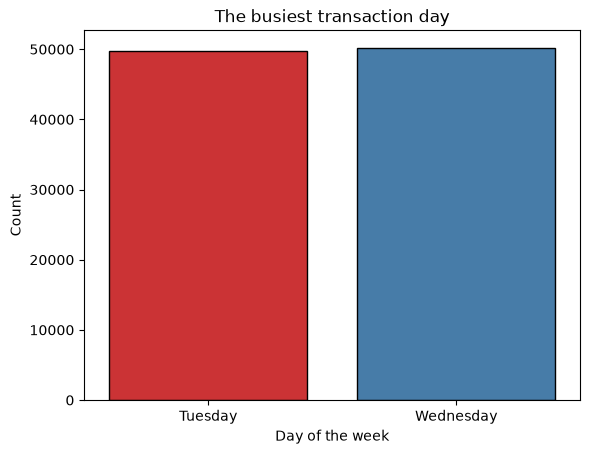

In [18]:
# The busiest transaction day

ax = sns.countplot(x = df['Day of Week'],palette = "Set1", edgecolor = "black")
ax.set_title('The busiest transaction day')
ax.set(xlabel = 'Day of the week')
ax.set(ylabel='Count')
plt.show()

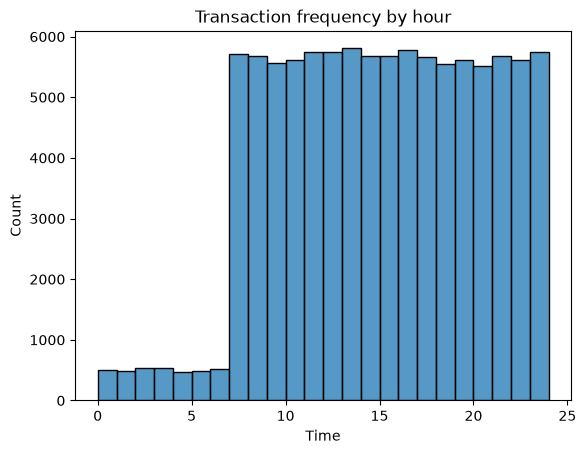

In [19]:
# Plot transaction frequency by hour

ax = sns.histplot(df['Time'], bins=24, fill=True, shrink=1, kde=False)
ax.set_title('Transaction frequency by hour')
plt.show()

# Few transactions occur between midnight and 7 AM

In [20]:
# Determine the most frequently used card

df['Type of Card'].value_counts()

Type of Card
Visa          53784
MasterCard    46167
Name: count, dtype: int64

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/1774362504.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = df['Type of Card'],palette = "Set1", edgecolor = "black")


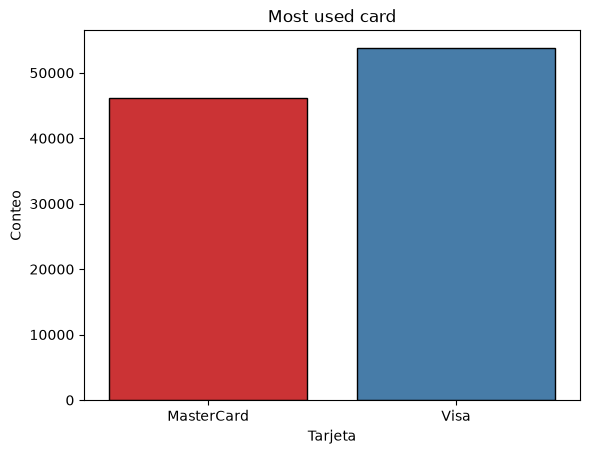

In [21]:
# Most used card

ax = sns.countplot(x = df['Type of Card'],palette = "Set1", edgecolor = "black")
ax.set_title('Most used card')
ax.set(xlabel = 'Tarjeta')
ax.set(ylabel='Conteo')
plt.show()

In [22]:
# Payment method according to card type

pd.crosstab(df['Entry Mode'],df['Type of Card'])

Type of Card,MasterCard,Visa
Entry Mode,,
CVC,15616,17848
PIN,22950,27001
Tap,7601,8935


In [23]:
# Payment method
df['Entry Mode'].value_counts()

Entry Mode
PIN    49951
CVC    33464
Tap    16536
Name: count, dtype: int64

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/2214183306.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = df['Entry Mode'],palette = "Set1", edgecolor = "black")


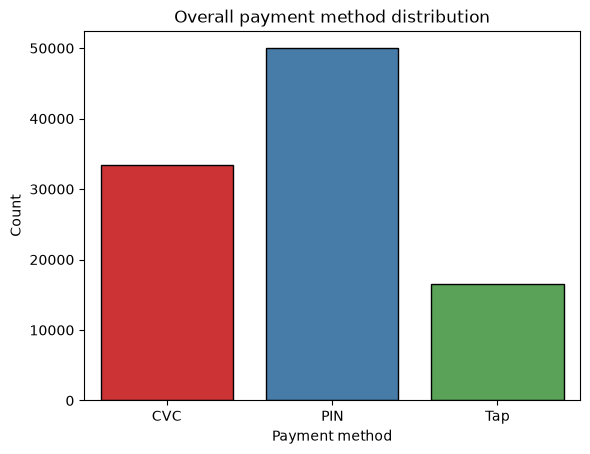

In [24]:
# Payment method

ax = sns.countplot(x = df['Entry Mode'],palette = "Set1", edgecolor = "black")
ax.set_title('Overall payment method distribution')
ax.set(xlabel = 'Payment method')
ax.set(ylabel='Count')
plt.show()

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/2466672205.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x = df['Entry Mode'], y= df['Amount'], palette = "Set1" )


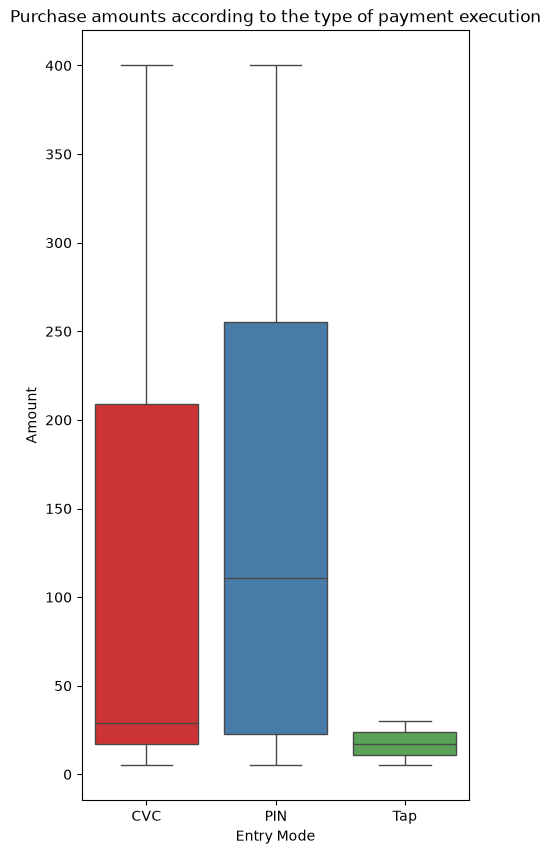

In [25]:
# Compare distributions across payment types

plt.figure(figsize=(5, 10))

ax = sns.boxplot(x = df['Entry Mode'], y= df['Amount'], palette = "Set1" )
ax.set_title('Purchase amounts according to the type of payment execution')
plt.show()

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/580960999.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = df['Merchant Group'],palette = "Set1" )


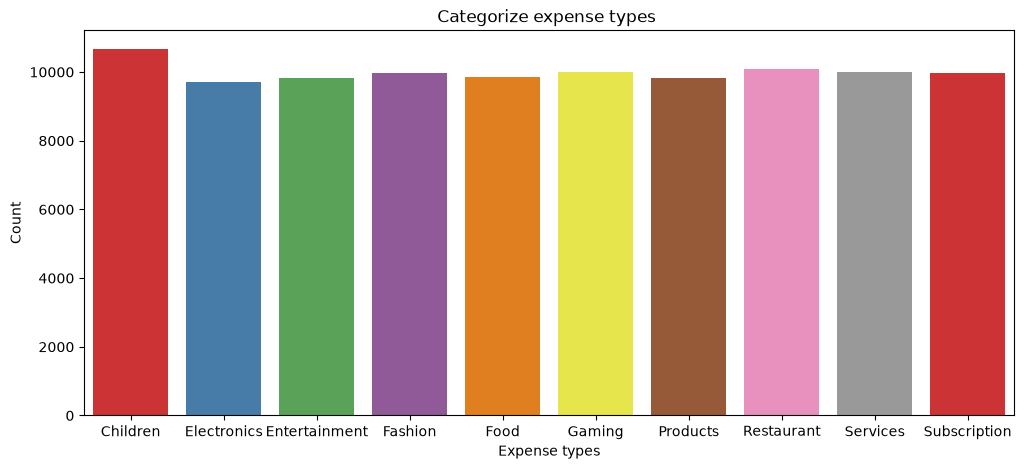

In [26]:
# Categorize expense types

plt.figure(figsize=(12, 5))

ax = sns.countplot(x = df['Merchant Group'],palette = "Set1" )
ax.set_title('Categorize expense types ')
ax.set(xlabel = 'Expense types')
ax.set(ylabel='Count')
plt.show()

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/768576470.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Country of Transaction'],palette = "Set1", ax=axes[0])
/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/768576470.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Shipping Address'],palette = "Set1",ax=axes[1])
/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/768576470.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Country of Residence'],palette = 

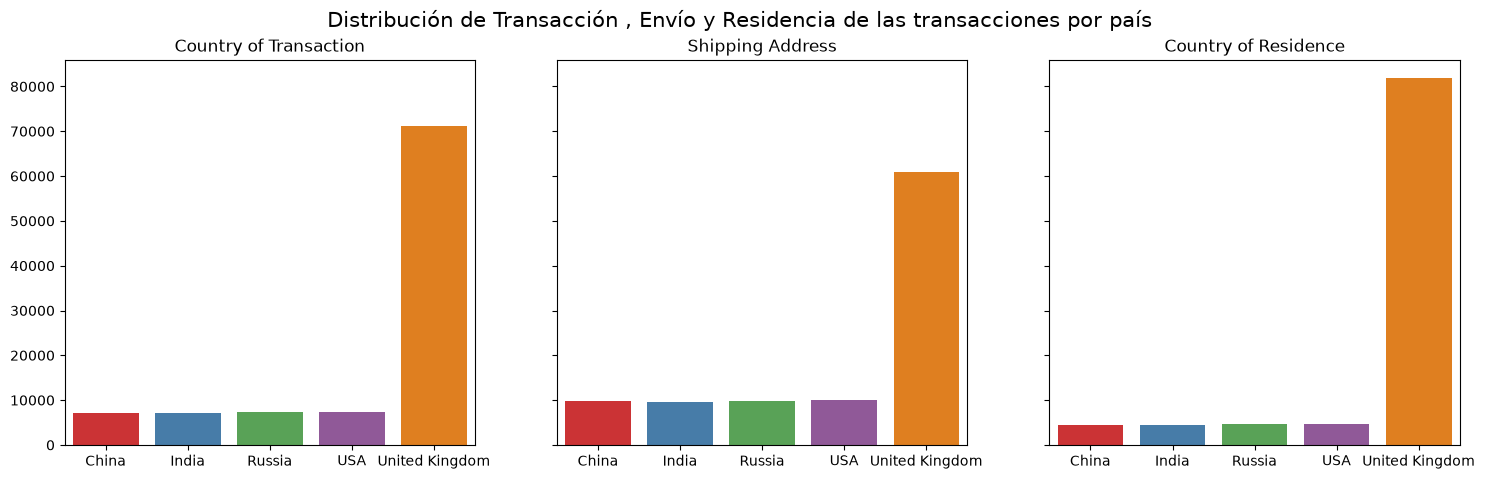

In [27]:
# Show transaction counts by country

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

sns.countplot(x = df['Country of Transaction'],palette = "Set1", ax=axes[0])
sns.countplot(x = df['Shipping Address'],palette = "Set1",ax=axes[1])
sns.countplot(x = df['Country of Residence'],palette = "Set1", ax=axes[2])


axes[0].set(xlabel='', ylabel='', title='Country of Transaction')
axes[1].set(xlabel='', ylabel='', title='Shipping Address')
axes[2].set(xlabel='', ylabel='', title='Country of Residence')


fig.suptitle('Distribución de Transacción , Envío y Residencia de las transacciones por país', fontsize=15);

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/574433076.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x = df['Gender'], y= df['Amount'],palette = "Set1" )


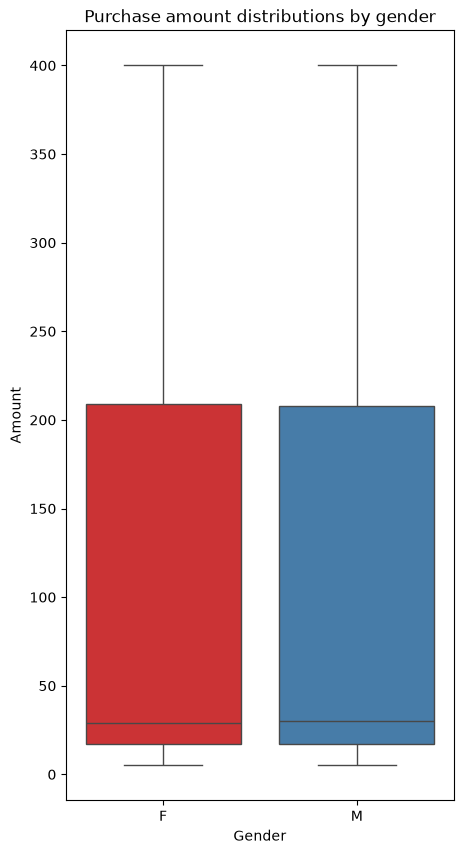

In [28]:
# Compare purchase amount distributions by gender

plt.figure(figsize=(5, 10))

ax = sns.boxplot(x = df['Gender'], y= df['Amount'],palette = "Set1" )
ax.set_title('Purchase amount distributions by gender')
ax.set(xlabel = 'Gender')
ax.set(ylabel='Amount')
plt.show()

In [29]:
# Filter data by gender

df_gender_F = df[df['Gender'] == 'F'].reset_index()
df_gender_M = df[df['Gender'] == 'M'].reset_index()

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/66195972.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df_gender_F['Merchant Group'],palette = "Set1", ax=axes[0])
/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/66195972.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df_gender_M['Merchant Group'],palette = "Set1",ax=axes[1])
/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/66195972.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='

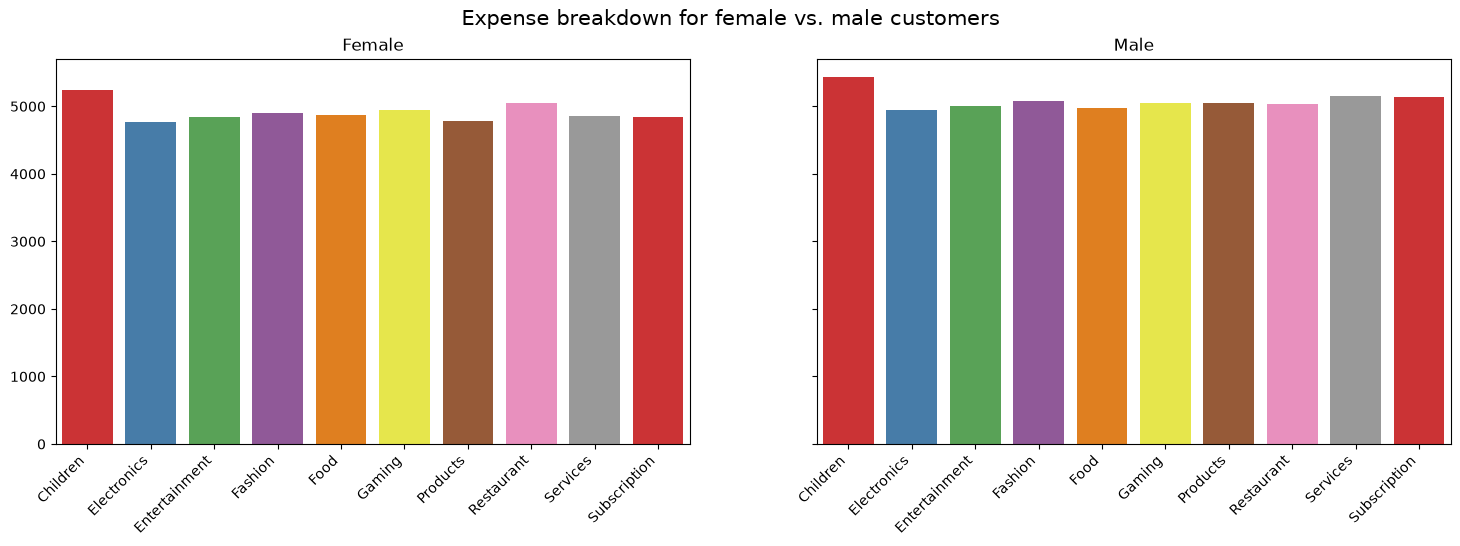

In [30]:
# Expense breakdown for female vs. male customers

fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=True, sharey=True)

sns.countplot(x = df_gender_F['Merchant Group'],palette = "Set1", ax=axes[0])
sns.countplot(x = df_gender_M['Merchant Group'],palette = "Set1",ax=axes[1])



axes[0].set(xlabel='', ylabel='', title='Female')
axes[1].set(xlabel='', ylabel='', title='Male')

axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


fig.suptitle('Expense breakdown for female vs. male customers', fontsize=15);

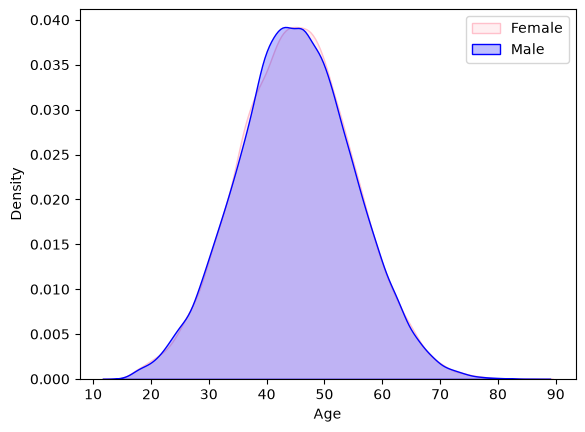

In [31]:
# Age density plots by gender

edad_femenina = df_gender_F['Age']
edad_masculina = df_gender_M['Age']

sns.kdeplot(edad_femenina,color='pink', label='Female',fill=True)
sns.kdeplot(edad_masculina, color='blue', label='Male',fill=True)

plt.legend()
plt.show()

In [32]:
# Number of fraud cases per bank

df_fraud = df[df['Fraud'] == True]
fraudes_bancarios = df_fraud.groupby('Bank')['Fraud'].count().reset_index()
fraudes_bancarios

,Bank,Fraud
0,Barclays,2981
1,HSBC,653
2,Halifax,678
3,Lloyds,693
4,Metro,804
5,Monzo,728
6,RBS,652


/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/1190279447.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = fraudes_bancarios['Bank'], y = fraudes_bancarios['Fraud'],palette = "Set1")


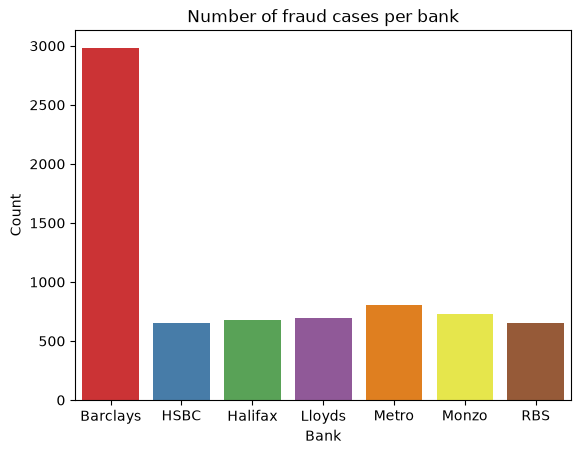

In [33]:
# Number of fraud cases per bank

ax = sns.barplot(x = fraudes_bancarios['Bank'], y = fraudes_bancarios['Fraud'],palette = "Set1")
ax.set_title('Number of fraud cases per bank')
ax.set(xlabel = 'Bank')
ax.set(ylabel='Count')
plt.show()

In [34]:
# Time slot with highest fraud incidence
fraudes_bancarios = df_fraud.groupby('Time')['Fraud'].count().reset_index()
fraudes_bancarios

,Time,Fraud
0,0,509
1,1,483
2,2,536
3,3,531
4,4,474
5,5,488
6,6,515
7,7,209
8,8,194
9,9,203


/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/4027026841.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = fraudes_bancarios['Time'], y = fraudes_bancarios['Fraud'],palette = "Set1" )


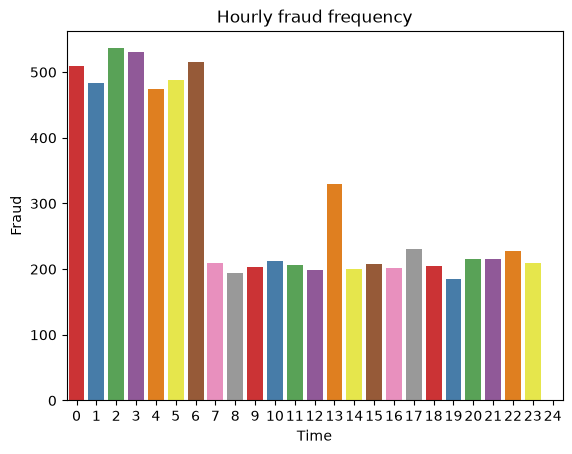

In [35]:
# Time slot with highest fraud incidence

ax = sns.barplot(x = fraudes_bancarios['Time'], y = fraudes_bancarios['Fraud'],palette = "Set1" )
ax.set_title('Hourly fraud frequency')
plt.show()

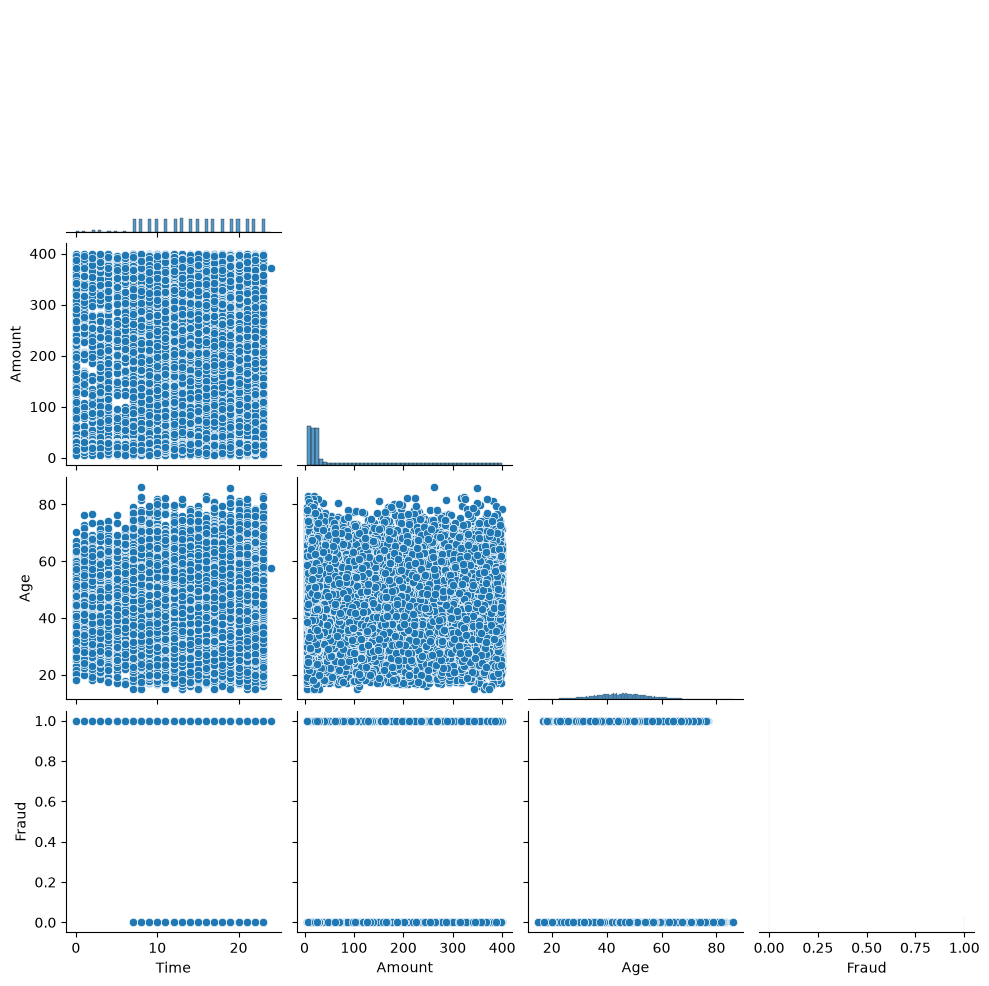

In [36]:
# Create pairplot of feature correlations
sns.pairplot(df,corner=True)

# EN | Encoding / ES | Codificación

In [37]:
df_modelo = df.iloc[:,2:]
df_modelo

,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,Wednesday,19,Visa,Tap,5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,False
1,Wednesday,17,MasterCard,PIN,288,POS,Services,USA,USA,USA,F,49.6,Lloyds,False
2,Wednesday,14,Visa,Tap,5,POS,Restaurant,India,India,India,F,42.2,Barclays,False
3,Tuesday,14,Visa,Tap,28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,False
4,Tuesday,23,Visa,CVC,91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Tuesday,22,MasterCard,Tap,15,POS,Electronics,United Kingdom,United Kingdom,United Kingdom,F,53.8,Halifax,False
99996,Wednesday,23,MasterCard,PIN,7,ATM,Children,Russia,Russia,Russia,M,45.0,Barclays,False
99997,Tuesday,11,MasterCard,PIN,21,ATM,Subscription,United Kingdom,United Kingdom,United Kingdom,F,46.5,HSBC,False
99998,Wednesday,22,Visa,Tap,25,POS,Products,United Kingdom,United Kingdom,United Kingdom,M,48.2,Barclays,False


In [38]:
df_modelo = pd.get_dummies(df_modelo)
df_modelo['Fraude'] = df_modelo['Fraud']  #REACOMODO DE LA COLUMNA Y
df_modelo = df_modelo.drop('Fraud',axis = 1)
df_modelo = df_modelo.reset_index()
df_modelo

,index,Time,Amount,Age,Day of Week_Tuesday,Day of Week_Wednesday,Type of Card_MasterCard,Type of Card_Visa,Entry Mode_CVC,Entry Mode_PIN,...,Gender_F,Gender_M,Bank_Barclays,Bank_HSBC,Bank_Halifax,Bank_Lloyds,Bank_Metro,Bank_Monzo,Bank_RBS,Fraude
0,0,19,5,25.2,False,True,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
1,1,17,288,49.6,False,True,True,False,False,True,...,True,False,False,False,False,True,False,False,False,False
2,2,14,5,42.2,False,True,False,True,False,False,...,True,False,True,False,False,False,False,False,False,False
3,3,14,28,51.0,True,False,False,True,False,False,...,True,False,True,False,False,False,False,False,False,False
4,4,23,91,38.0,True,False,False,True,True,False,...,False,True,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99946,99995,22,15,53.8,True,False,True,False,False,False,...,True,False,False,False,True,False,False,False,False,False
99947,99996,23,7,45.0,False,True,True,False,False,True,...,False,True,True,False,False,False,False,False,False,False
99948,99997,11,21,46.5,True,False,True,False,False,True,...,True,False,False,True,False,False,False,False,False,False
99949,99998,22,25,48.2,False,True,False,True,False,False,...,False,True,True,False,False,False,False,False,False,False


# EN | Standardization / ES | Estandarización

In [39]:
#https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html  
# Reference: MinMaxScaler documentation
#MinMaxScaler rescales the data set such that all feature values are in the range [0, 1]

scaler = MinMaxScaler()

Time_Amount_Age_Scalado = df_modelo[['Time','Amount','Age']]

Time_Amount_Age_Scalado = pd.DataFrame(scaler.fit_transform(Time_Amount_Age_Scalado), columns=Time_Amount_Age_Scalado.columns)
print(Time_Amount_Age_Scalado)

df_modelo = df_modelo.drop(['index','Time','Amount','Age'],axis = 1)

           Time    Amount       Age
0      0.791667  0.000000  0.143460
1      0.708333  0.716456  0.486639
2      0.583333  0.000000  0.382560
3      0.583333  0.058228  0.506329
4      0.958333  0.217722  0.323488
...         ...       ...       ...
99946  0.916667  0.025316  0.545710
99947  0.958333  0.005063  0.421941
99948  0.458333  0.040506  0.443038
99949  0.916667  0.050633  0.466948
99950  0.666667  0.559494  0.234880

[99951 rows x 3 columns]


# EN | X and y without balancing / ES | X e y sin balancear

In [40]:
X = pd.concat([Time_Amount_Age_Scalado,df_modelo], axis = 1)
X = X.drop('Fraude',axis = 1)

y = df_modelo['Fraude']

print(X.shape)
print(y.shape)

(99951, 47)
(99951,)


/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/906698042.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = y, palette = "Set1", edgecolor = "black")


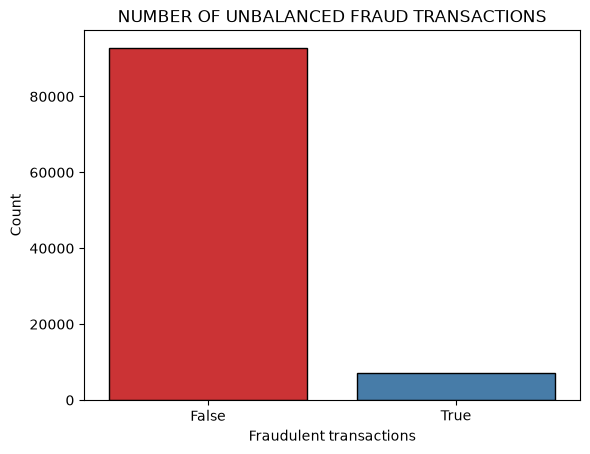

In [41]:
ax = sns.countplot(x = y, palette = "Set1", edgecolor = "black")
ax.set_title('NUMBER OF UNBALANCED FRAUD TRANSACTIONS')
ax.set(xlabel = 'Fraudulent transactions')
ax.set(ylabel='Count')
plt.show()

In [42]:
# Split data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(69965, 47)
(29986, 47)
(69965,)
(29986,)


# EN | X and y with oversampling / ES | X e y con sobremuestreo (Oversampling)

In [43]:
#https://imbalanced-learn.org/stable/over_sampling.html  
# Reference: imbalanced-learn oversampling
#One way to fight this issue is to generate new samples in the classes which are under-represented. The most naive strategy is to generate new samples by randomly sampling with replacement the current available samples.

In [44]:
# Initialize the RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_oversampler, y_oversampler = ros.fit_resample(X, y)

In [45]:
y_oversampler

0         False
1         False
2         False
3         False
4          True
          ...  
185519     True
185520     True
185521     True
185522     True
185523     True
Name: Fraude, Length: 185524, dtype: bool

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/3546748446.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = y_oversampler, palette = "Set1", edgecolor = "black")


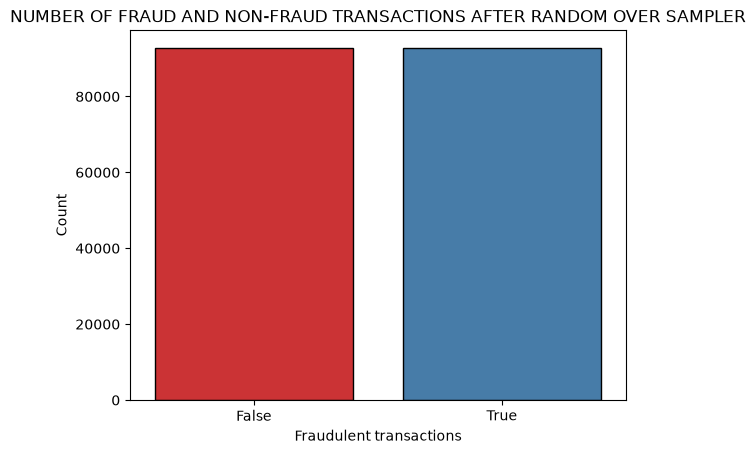

In [46]:
ax = sns.countplot(x = y_oversampler, palette = "Set1", edgecolor = "black")
ax.set_title('NUMBER OF FRAUD AND NON-FRAUD TRANSACTIONS AFTER RANDOM OVER SAMPLER')
ax.set(xlabel = 'Fraudulent transactions')
ax.set(ylabel='Count')
plt.show()

In [47]:
# Split data into training and test sets

X_train_ros, X_test_ros, y_train_ros, y_test_ros = train_test_split(X_oversampler, y_oversampler, test_size=0.3)
print(X_train_ros.shape)
print(X_test_ros.shape)
print(y_train_ros.shape)
print(y_test_ros.shape)

(129866, 47)
(55658, 47)
(129866,)
(55658,)


# EN | X and y with undersampling / ES | X e y con submuestreo (Undersampling)

In [48]:
#https://imbalanced-learn.org/stable/over_sampling.html  
# Reference: imbalanced-learn oversampling
#Prototype generation technique will reduce the number of samples in the targeted classes but the remaining samples are generated — and not selected — from the original set.

In [49]:
# Initialize the RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

# Apply undersampling to the training data
X_undersampler, y_undersampler = rus.fit_resample(X, y)

/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25231/1270758482.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = y_undersampler, palette = "Set1", edgecolor = "black")


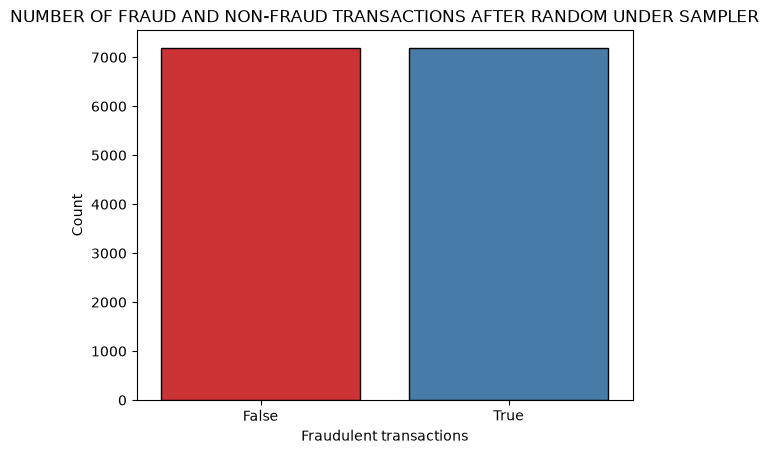

In [50]:
ax = sns.countplot(x = y_undersampler, palette = "Set1", edgecolor = "black")
ax.set_title('NUMBER OF FRAUD AND NON-FRAUD TRANSACTIONS AFTER RANDOM UNDER SAMPLER')
ax.set(xlabel = 'Fraudulent transactions')
ax.set(ylabel='Count')
plt.show()

In [51]:
X_train_rus, X_test_rus, y_train_rus, y_test_rus = train_test_split(X_undersampler, y_undersampler, test_size=0.3)
print(X_train_rus.shape)
print(X_test_rus.shape)
print(y_train_rus.shape)
print(y_test_rus.shape)

(10064, 47)
(4314, 47)
(10064,)
(4314,)


# EN | Data Cross-Validation / ES | Validación Cruzada de Datos

In [52]:
# Perform cross-validation

kf = KFold(n_splits=100, shuffle=True, random_state=42)


# EN | Modeling the Data / ES | Modelado de los Datos

## EN | Logistic Regression / ES | Regresión Logística

In [53]:
# Train logistic regression on unbalanced data

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
score = logreg.score(X_test, y_test)
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
print("Score sin validación cruzada: ", score)

Score sin validación cruzada:  0.9716200893750417


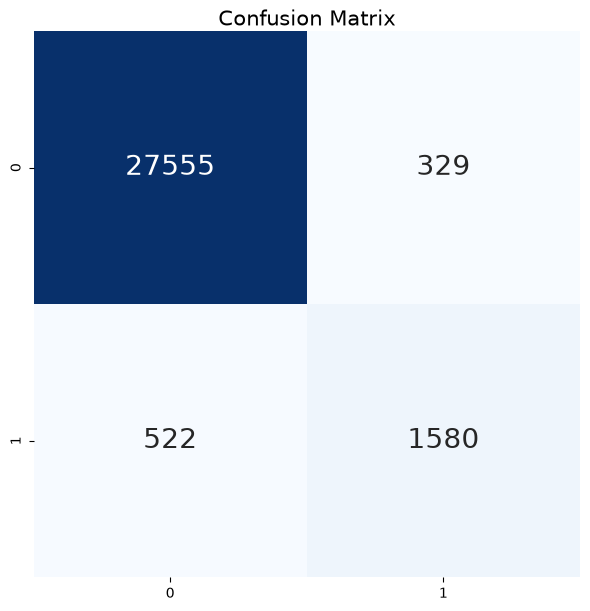

In [54]:
# Generate confusion matrix

class_names=[0,1] # name  of classes
fig, ax = plt.subplots(figsize=(6, 6))
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Plot confusion matrix as heatmap

sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="Blues" ,fmt='g', cbar=False, annot_kws={"size": 20})
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.ylabel('', fontsize=15, y=0.5)
plt.xlabel('Confusion Matrix', fontsize=15);

In [55]:
# Evaluate metrics with cross-validation
#https://scikit-learn.org/stable/modules/cross_validation.html
# Reference: scikit-learn cross-validation

cross_val_exactitud = cross_val_score(logreg, X_test, y_test, cv=kf)
print("Exactitud por cada fold:", cross_val_exactitud)
print("Exactitud promedio:", np.mean(cross_val_exactitud))
print("----------------------------------")

cross_val_f1 = cross_val_score(logreg, X_test, y_test, cv=kf, scoring='f1')
print("F1 score por cada fold:", cross_val_f1)
print("F1 score promedio:", np.mean(cross_val_f1))
print("----------------------------------")

cross_val_precision = cross_val_score(logreg, X_test, y_test, cv=kf, scoring='precision')
print("Precisión por cada fold:", cross_val_precision)
print("Precisión promedio:", np.mean(cross_val_precision))
print("----------------------------------")

cross_val_recall = cross_val_score(logreg, X_test, y_test, cv=kf, scoring='recall')
print("Sensbilidad  por cada fold:", cross_val_recall)
print("Sensbilidad  promedio:", np.mean(cross_val_recall))
print("----------------------------------")

Exactitud por cada fold: [0.96666667 0.96666667 0.97666667 0.97       0.97666667 0.98
 0.96333333 0.97       0.98666667 0.98666667 0.99333333 0.97666667
 0.98       0.96666667 0.98       0.96333333 0.96333333 0.99666667
 0.97333333 0.96333333 0.96666667 0.98666667 0.97       0.97666667
 0.96666667 0.96       0.96       0.95666667 0.95666667 0.98
 0.97       0.96333333 0.97333333 0.96333333 0.98666667 0.97666667
 0.98333333 0.97       0.97666667 0.96       0.97333333 0.96
 0.98666667 0.97666667 0.95666667 0.98       0.98333333 0.96666667
 0.97333333 0.97666667 0.96333333 0.96666667 0.97333333 0.97
 0.96       0.97333333 0.96666667 0.96       0.96666667 0.97666667
 0.96333333 0.97333333 0.99       0.98       0.95       0.97666667
 0.97666667 0.96333333 0.96666667 0.97666667 0.98       0.97666667
 0.96       0.98       0.97333333 0.96       0.98666667 0.97333333
 0.96666667 0.97333333 0.97333333 0.97333333 0.97333333 0.98
 0.97       0.98333333 0.97658863 0.97993311 0.9632107  0.96655518


In [56]:
# Logistic regression on oversampled data

logreg_ros = LogisticRegression()
logreg_ros.fit(X_train_ros, y_train_ros)
y_pred_ros = logreg_ros.predict(X_test_ros)
score_ros = logreg_ros.score(X_test_ros, y_test_ros)
cnf_matrix_ros = metrics.confusion_matrix(y_test_ros, y_pred_ros)
print("Score sin validación cruzada: ", score_ros)

Score sin validación cruzada:  0.9375471630313702


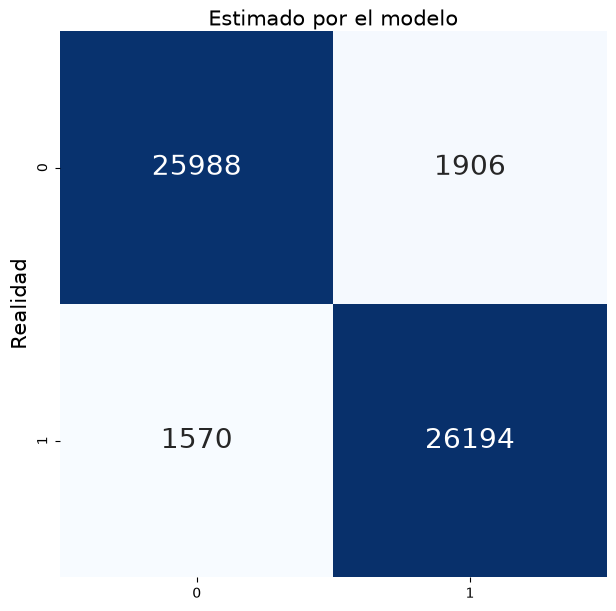

In [57]:
# Compute confusion matrix and plot it using Seaborn

class_names=[0,1] # name  of classes
fig, ax = plt.subplots(figsize=(6, 6))
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_ros), annot=True, cmap="Blues" ,fmt='g', cbar=False, annot_kws={"size": 20})
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.ylabel('Realidad', fontsize=15, y=0.5)
plt.xlabel('Estimado por el modelo', fontsize=15);

In [58]:
# ROS metrics with cross-validation

cross_val_exactitud_ros = cross_val_score(logreg_ros, X_test_ros, y_test_ros, cv=kf)
print("Exactitud por cada fold:", cross_val_exactitud_ros)
print("Exactitud promedio:", np.mean(cross_val_exactitud_ros))
print("----------------------------------")

cross_val_f1_ros = cross_val_score(logreg_ros, X_test_ros, y_test_ros, cv=kf, scoring='f1')
print("F1 score por cada fold:", cross_val_f1_ros)
print("F1 score promedio:", np.mean(cross_val_f1_ros))
print("----------------------------------")

cross_val_precision_ros = cross_val_score(logreg_ros, X_test_ros, y_test_ros, cv=kf, scoring='precision')
print("Precisión por cada fold:", cross_val_precision_ros)
print("Precisión promedio:", np.mean(cross_val_precision_ros))
print("----------------------------------")

cross_val_recall_ros = cross_val_score(logreg_ros, X_test_ros, y_test_ros, cv=kf, scoring='recall')
print("Sensbilidad  por cada fold:", cross_val_recall_ros)
print("Sensbilidad  promedio:", np.mean(cross_val_recall_ros))
print("----------------------------------")

Exactitud por cada fold: [0.92639138 0.92100539 0.93536804 0.94254937 0.94614004 0.94614004
 0.9443447  0.93716338 0.93177738 0.92639138 0.93536804 0.92998205
 0.9443447  0.93716338 0.9443447  0.94254937 0.92639138 0.93536804
 0.92998205 0.93716338 0.92998205 0.92639138 0.91921005 0.94793537
 0.94614004 0.92639138 0.94254937 0.93357271 0.94254937 0.94793537
 0.93895871 0.93536804 0.94075404 0.92639138 0.93536804 0.95691203
 0.93895871 0.9497307  0.94614004 0.96229803 0.91921005 0.94075404
 0.94793537 0.93895871 0.92639138 0.94075404 0.93895871 0.92100539
 0.91023339 0.93716338 0.92280072 0.92998205 0.93357271 0.94075404
 0.95152603 0.92818671 0.92280072 0.92818671 0.93345324 0.93165468
 0.94244604 0.95683453 0.9442446  0.93884892 0.94064748 0.94784173
 0.95503597 0.92625899 0.93884892 0.93705036 0.92446043 0.92985612
 0.94064748 0.92805755 0.93345324 0.95143885 0.93884892 0.93705036
 0.92625899 0.91906475 0.93884892 0.9442446  0.93165468 0.92985612
 0.93165468 0.94604317 0.9352518  0.9

In [59]:
# LOGISTIC REGRESSION RANDOM UNDER SAMPLER

logreg_rus = LogisticRegression()
logreg_rus.fit(X_train_rus, y_train_rus)
y_pred_rus = logreg_rus.predict(X_test_rus)
score_rus = logreg_rus.score(X_test_rus, y_test_rus)
cnf_matrix_rus = metrics.confusion_matrix(y_test_rus, y_pred_rus)
print("Score sin validación cruzada: ", score_rus)

Score sin validación cruzada:  0.9392675011590171


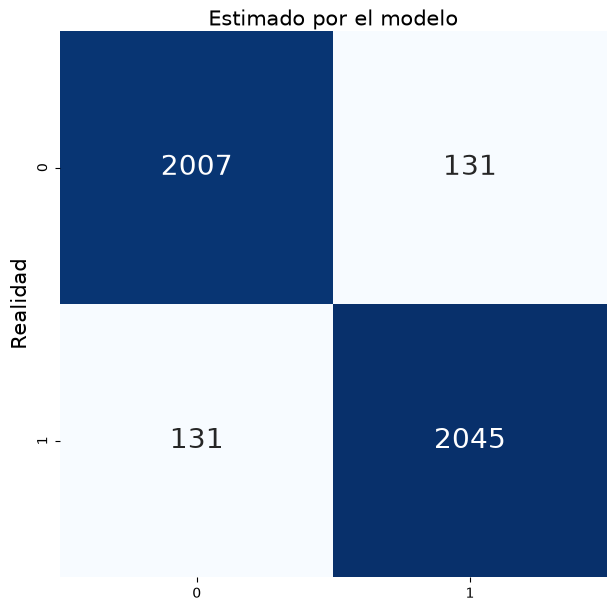

In [60]:
# Compute confusion matrix and plot it using Seaborn

class_names=[0,1] # name  of classes
fig, ax = plt.subplots(figsize=(6, 6))
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_rus), annot=True, cmap="Blues" ,fmt='g', cbar=False, annot_kws={"size": 20})
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.ylabel('Realidad', fontsize=15, y=0.5)
plt.xlabel('Estimado por el modelo', fontsize=15);

In [61]:
# RUS metrics with cross-validation

cross_val_exactitud_rus = cross_val_score(logreg_rus, X_test_rus, y_test_rus, cv=kf)
print("Exactitud por cada fold:", cross_val_exactitud_rus)
print("Exactitud promedio:", np.mean(cross_val_exactitud_rus))
print("----------------------------------")

cross_val_f1_rus = cross_val_score(logreg_rus, X_test_rus, y_test_rus, cv=kf, scoring='f1')
print("F1 score por cada fold:", cross_val_f1_rus)
print("F1 score promedio:", np.mean(cross_val_f1_rus))
print("----------------------------------")

cross_val_precision_rus = cross_val_score(logreg_rus, X_test_rus, y_test_rus, cv=kf, scoring='precision')
print("Precisión por cada fold:", cross_val_precision_rus)
print("Precisión promedio:", np.mean(cross_val_precision_rus))
print("----------------------------------")

cross_val_recall_rus = cross_val_score(logreg_rus, X_test_rus, y_test_rus, cv=kf, scoring='recall')
print("Sensbilidad  por cada fold:", cross_val_recall_rus)
print("Sensbilidad  promedio:", np.mean(cross_val_recall_rus))
print("----------------------------------")

Exactitud por cada fold: [0.95454545 0.88636364 0.97727273 0.93181818 0.88636364 0.97727273
 0.88636364 0.95454545 0.95454545 0.90909091 0.95454545 0.88636364
 0.86363636 0.95454545 0.90697674 1.         0.90697674 0.95348837
 0.90697674 0.90697674 1.         0.93023256 0.95348837 0.86046512
 1.         0.93023256 0.90697674 0.95348837 1.         0.90697674
 0.93023256 0.93023256 0.97674419 0.93023256 1.         0.95348837
 0.90697674 0.90697674 0.97674419 0.95348837 0.88372093 0.95348837
 0.90697674 0.90697674 0.93023256 0.86046512 0.93023256 0.93023256
 0.95348837 0.86046512 0.95348837 0.97674419 0.95348837 0.93023256
 0.95348837 0.95348837 0.86046512 1.         1.         0.90697674
 0.95348837 0.97674419 0.90697674 0.93023256 0.88372093 0.90697674
 0.95348837 0.95348837 0.86046512 0.93023256 0.97674419 0.90697674
 0.88372093 0.97674419 0.95348837 0.90697674 0.97674419 1.
 0.93023256 0.88372093 0.95348837 1.         0.90697674 0.95348837
 1.         0.90697674 1.         0.97674419 

### EN | LOGISTIC REGRESSION RESULTS INTERPRETATION
### ES | INTERPRETACIÓN DE LOS RESULTADOS DE REGRESIÓN LOGÍSTICA

Para este modelo se utilizaron las medidas de exactitud o accuracy , F1 Score, precisión y recall o sensibilidad.

**La Exactitud o Accuracy** es el porcentaje de predicciones correctas, tanto si era Fraude y fue clasificado correctamente como si NO era fraude y fue clasificado correctamente.

**F1 Score** fue una variable importante para este proyecto ya que nos resume la precisión y recall/sensibilidad en una sola métrica. Por ello es de gran utilidad cuando la distribución de las clases es desigual caso que tuvimos en nuestro dataset.

**Precisión** es el cociente entre los casos positivos bien clasificados por el modelo y el total de clasificaciones. En forma práctica es  el porcentaje de casos positivos detectados. Era fraude y se clasifico correctamente.

**Recall o Sensibilidad** es la proporción entre los casos positivos bien clasificados por el modelo, respecto al total de positivos reales.

---

EN | **English version:**

For this model we used the accuracy, F1 Score, precision, and recall (sensitivity) metrics.

**Accuracy** is the percentage of correct predictions, whether it was Fraud and was correctly classified or it was NOT fraud and was correctly classified.

**F1 Score** was an important metric for this project since it summarizes precision and recall in a single value. This makes it especially useful when the class distribution is imbalanced, as was the case in our dataset.

**Precision** is the ratio between the positive cases correctly classified by the model and the total number of positive classifications. In practical terms, it's the percentage of detected positive cases that were actually fraud and were correctly classified.

**Recall (Sensitivity)** is the proportion of positive cases correctly classified by the model relative to the total number of actual positives.

Cabe resaltar que se crearon 3 diferentes modelos del mismo tipo (Regresión Logística y Decision Tree)

Se crearon 3 diferentes modelos ya que cada uno de ellos se basó en diferentes datos de entrenamiento, prueba y predicción. El primer modelo fue entrenado con datos sin balancear, el segundo modelo utilizó datos con RandomOverSampler y el tercer modelo utilizó datos con RandomUnderSampler.

---

EN | **English version:**

It's worth noting that 3 different models of the same type were created (Logistic Regression and Decision Tree).

Three different models were created because each one was based on different training, test, and prediction data. The first model was trained on unbalanced data, the second model used data with RandomOverSampler, and the third model used data with RandomUnderSampler.

En el primer modelo pudimos observar que hay una buena exactitud de la clasificación, sin embargo era poco sensible, es decir se le escapaban muchos casos de fraude.

La precisión y la sensibilidad eran considerablemente bajas, por lo que la F1 Score también lo era. Debido a este detalle fue como se aplicó la técnica de balanceo de datos.

Posterior a este balanceo de datos las métricas en general presentaron un buen desempeño. Llegando a estar en alrededor de 93%. Sin embargo no tan bueno como el siguiente modelo a analizar.

---

EN | **English version:**

In the first model we observed good classification accuracy; however, it had low sensitivity, meaning it missed many fraud cases.

Precision and recall were considerably low, and as a result, so was the F1 Score. This is why the data balancing technique was applied.

After balancing the data, the metrics generally showed good performance, reaching around 93%. However, not as good as the next model to be analyzed.

## EN | Decision Tree / ES | Árbol de Decisión

In [62]:
# Build model with default parameters
mod_tree_class = DecisionTreeClassifier(random_state=42)

# Fit and evaluate on original unbalanced set
mod_tree_class.fit(X_train, y_train)
y_pred = mod_tree_class.predict(X_test)

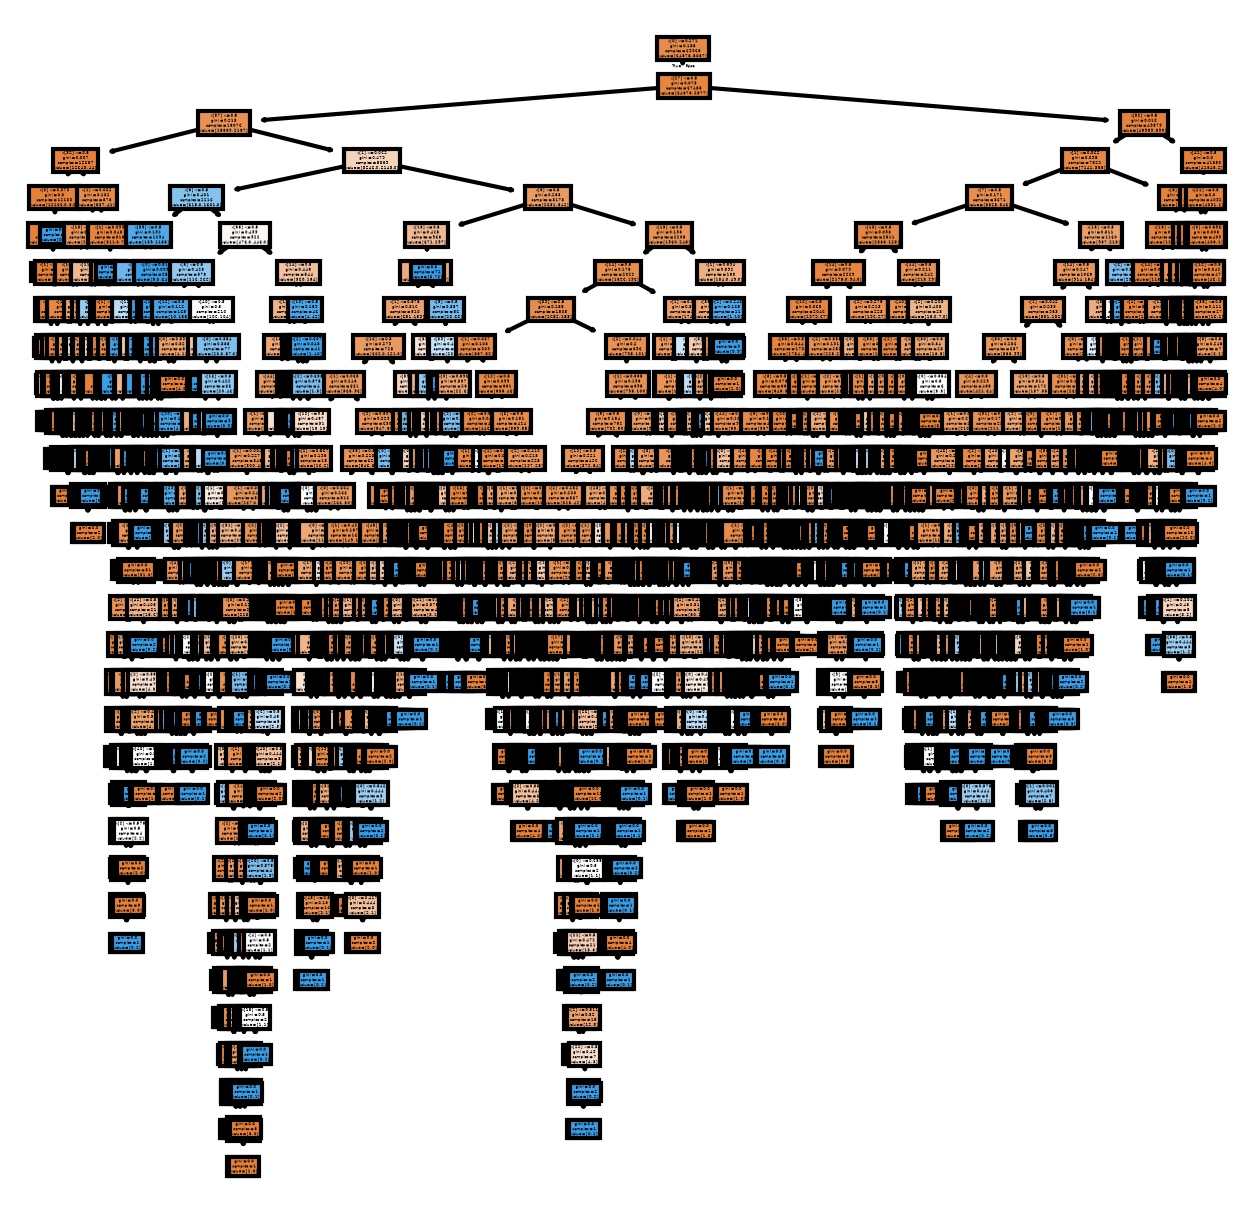

In [63]:
plt.figure(figsize = (5,5), dpi = 300)
treeClassifier.plot_tree(mod_tree_class,filled = True);
plt.show()

In [64]:
# Fit on the oversampled dataset
mod_tree_class_ros = DecisionTreeClassifier(random_state=42)

# Fit and evaluate oversampled (ROS)
mod_tree_class_ros.fit(X_train_ros, y_train_ros)
y_pred_ros = mod_tree_class.predict(X_test_ros)

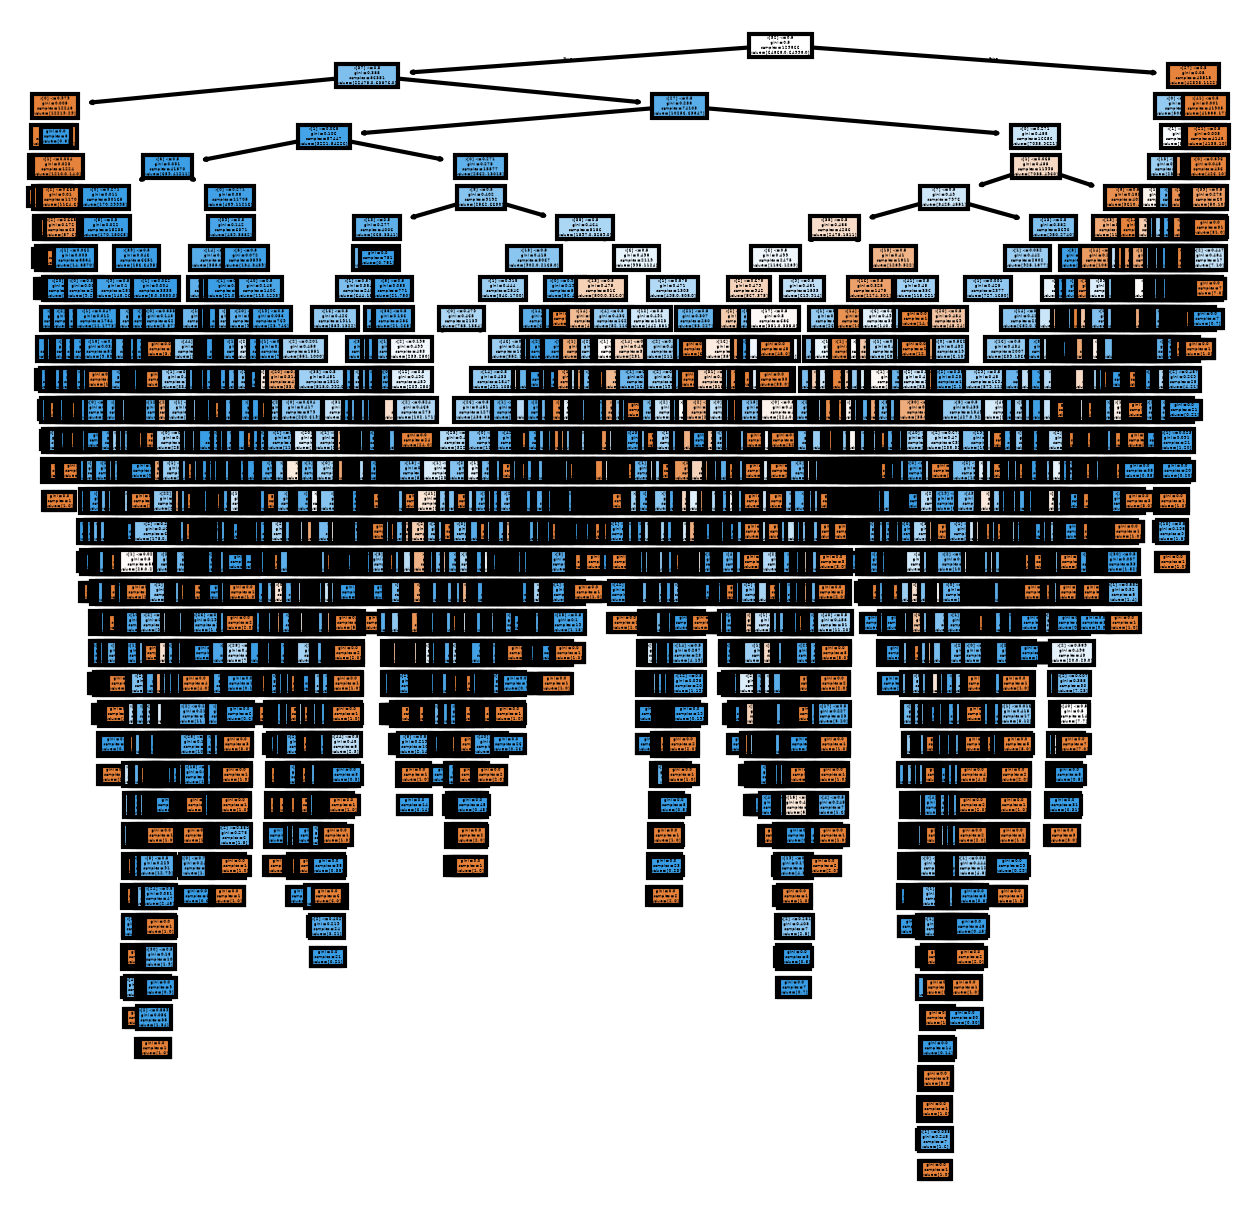

In [65]:
plt.figure(figsize = (5,5), dpi = 300)
treeClassifier.plot_tree(mod_tree_class_ros,filled = True);
plt.show()

In [66]:
 # Fit on the undersampled dataset
mod_tree_class_rus = DecisionTreeClassifier(random_state=42)

# Fit and evaluateundersampled (RUS)
mod_tree_class_rus.fit(X_train_rus, y_train_rus)
y_pred_rus = mod_tree_class.predict(X_test_rus)

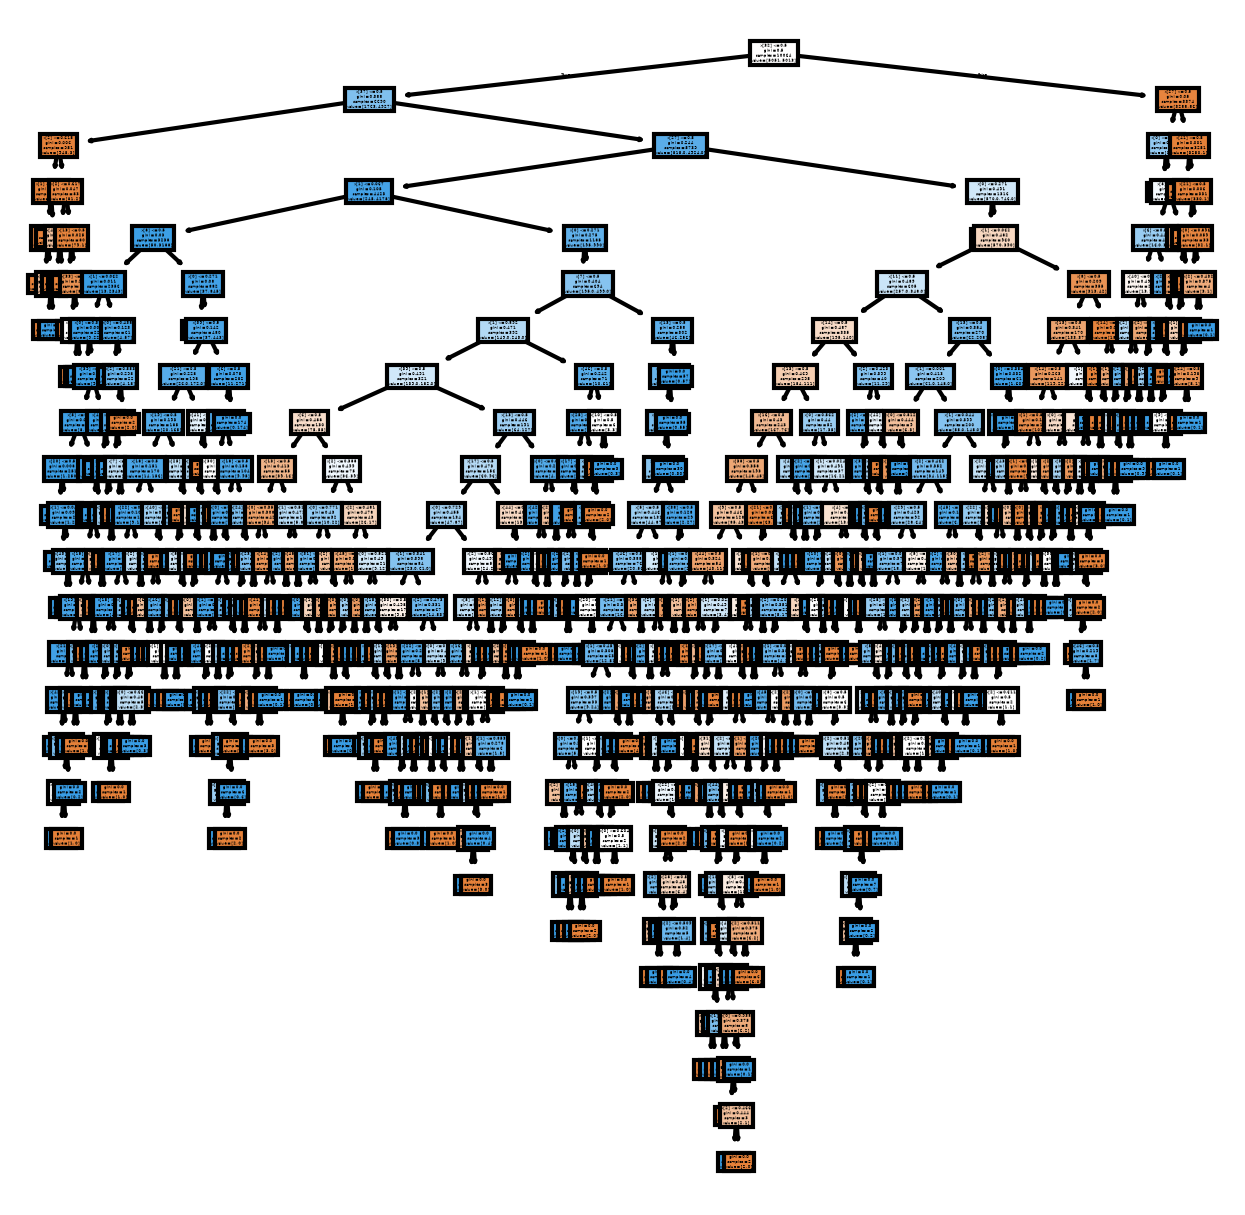

In [67]:
plt.figure(figsize = (5,5), dpi = 300)
treeClassifier.plot_tree(mod_tree_class_rus,filled = True);
plt.show()

### EN | DECISION TREE METRICS
### ES | MÉTRICAS DE ÁRBOL DE DECISIÓN

Exactitud por cada fold: [0.97333333 0.98       0.98       0.97       0.98       0.98333333
 0.96333333 0.97666667 0.98666667 0.99333333 0.98666667 0.98333333
 0.97666667 0.97333333 0.99333333 0.98333333 0.98       0.99333333
 0.97       0.95333333 0.96666667 0.98666667 0.96333333 0.95333333
 0.97333333 0.96666667 0.97       0.96333333 0.98       0.97666667
 0.96666667 0.98       0.97       0.97       0.97666667 0.97
 0.99333333 0.97333333 0.95666667 0.97666667 0.97333333 0.98333333
 0.98       0.96333333 0.96666667 0.97333333 0.96       0.99
 0.98666667 0.98333333 0.97333333 0.96333333 0.98       0.96666667
 0.97333333 0.96666667 0.96666667 0.97333333 0.97666667 0.98
 0.96333333 0.99       0.99       0.98666667 0.96333333 0.98666667
 0.97666667 0.97       0.96       0.99       0.98666667 0.98333333
 0.97       0.98       0.96666667 0.97333333 0.98666667 0.99
 0.97666667 0.98333333 0.98       0.98       0.97666667 0.97333333
 0.96666667 0.97666667 0.96989967 0.98327759 0.98327759 0.956

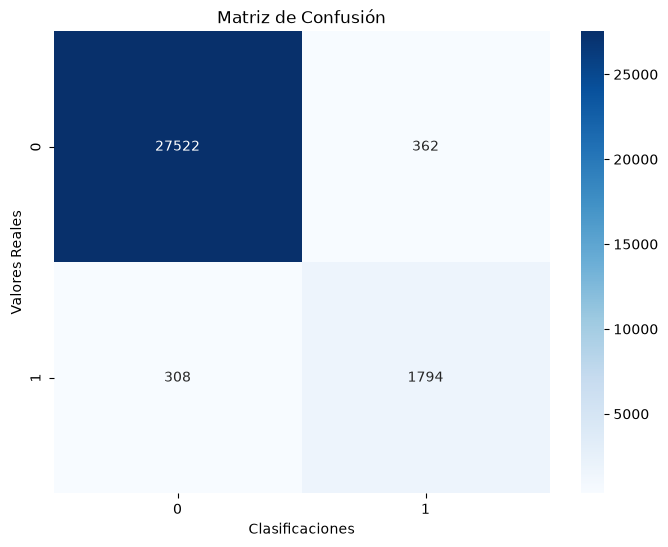

In [68]:
# Unbalanced

cross_val_exactitud = cross_val_score(mod_tree_class, X_test, y_test, cv=kf)
print("Exactitud por cada fold:", cross_val_exactitud)
print("Exactitud promedio:", np.mean(cross_val_exactitud))
print("----------------------------------")

cross_val_f1 = cross_val_score(mod_tree_class, X_test, y_test, cv=kf, scoring='f1')
print("F1 score por cada fold:", cross_val_f1)
print("F1 score promedio:", np.mean(cross_val_f1))
print("----------------------------------")

cross_val_precision = cross_val_score(mod_tree_class, X_test, y_test, cv=kf, scoring='precision')
print("Precisión por cada fold:", cross_val_precision)
print("Precisión promedio:", np.mean(cross_val_precision))
print("----------------------------------")

cross_val_recall = cross_val_score(mod_tree_class, X_test, y_test, cv=kf, scoring='recall')
print("Sensbilidad  por cada fold:", cross_val_recall)
print("Sensbilidad  promedio:", np.mean(cross_val_recall))
print("----------------------------------")


# Compute confusion matrix and plot it using Seaborn
confusion = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")

plt.xlabel('Clasificaciones')
plt.ylabel('Valores Reales')
plt.title('Matriz de Confusión')
plt.show()

Exactitud por cada fold: [0.98204668 0.98384201 0.98563734 0.98384201 0.97486535 0.98743268
 0.99102334 0.98743268 0.97845601 0.98743268 0.98743268 0.98922801
 0.98563734 0.98563734 0.99102334 0.98025135 0.97666068 0.98922801
 0.98743268 0.98922801 0.97486535 0.97845601 0.98384201 0.99102334
 0.98384201 0.98384201 0.98563734 0.98563734 0.97845601 0.98384201
 0.98922801 0.98384201 0.97845601 0.97845601 0.98204668 0.98922801
 0.99102334 0.98922801 0.98743268 0.98204668 0.97845601 0.99102334
 0.99281867 0.98563734 0.98922801 0.97845601 0.99102334 0.97127469
 0.96947935 0.98025135 0.97666068 0.98025135 0.97845601 0.97307002
 0.994614   0.96947935 0.97486535 0.98384201 0.98021583 0.98201439
 0.99100719 0.99100719 0.99460432 0.97482014 0.98201439 0.97661871
 0.99100719 0.98381295 0.98561151 0.97841727 0.97841727 0.99460432
 0.98741007 0.99100719 0.98561151 0.98381295 0.98021583 0.98920863
 0.98741007 0.98381295 0.99100719 0.98561151 0.98920863 0.99280576
 0.98920863 0.98561151 0.98381295 0.9

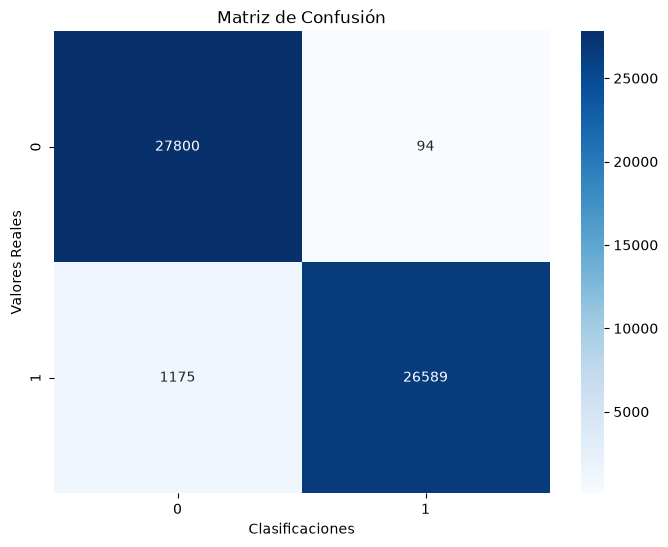

In [69]:
# Oversampler results

cross_val_exactitud_ros = cross_val_score(mod_tree_class_ros, X_test_ros, y_test_ros, cv=kf)
print("Exactitud por cada fold:", cross_val_exactitud_ros)
print("Exactitud promedio:", np.mean(cross_val_exactitud_ros))
print("----------------------------------")

cross_val_f1_ros = cross_val_score(mod_tree_class_ros, X_test_ros, y_test_ros, cv=kf, scoring='f1')
print("F1 score por cada fold:", cross_val_f1_ros)
print("F1 score promedio:", np.mean(cross_val_f1_ros))
print("----------------------------------")

cross_val_precision_ros = cross_val_score(mod_tree_class_ros, X_test_ros, y_test_ros, cv=kf, scoring='precision')
print("Precisión por cada fold:", cross_val_precision_ros)
print("Precisión promedio:", np.mean(cross_val_precision_ros))
print("----------------------------------")

cross_val_recall_ros = cross_val_score(mod_tree_class_ros, X_test_ros, y_test_ros, cv=kf, scoring='recall')
print("Sensbilidad  por cada fold:", cross_val_recall_ros)
print("Sensbilidad  promedio:", np.mean(cross_val_recall_ros))
print("----------------------------------")




confusion = confusion_matrix(y_test_ros, y_pred_ros)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")

plt.xlabel('Clasificaciones')
plt.ylabel('Valores Reales')
plt.title('Matriz de Confusión')
plt.show()

Exactitud por cada fold: [0.93181818 0.93181818 1.         0.93181818 0.93181818 0.97727273
 0.90909091 0.93181818 0.93181818 0.90909091 0.97727273 0.90909091
 0.86363636 0.95454545 0.88372093 1.         0.88372093 0.90697674
 0.95348837 0.88372093 0.95348837 0.90697674 0.90697674 0.95348837
 0.95348837 0.93023256 0.90697674 0.95348837 0.95348837 0.95348837
 0.93023256 0.90697674 0.95348837 0.93023256 1.         0.95348837
 0.95348837 0.88372093 0.95348837 0.93023256 0.81395349 0.95348837
 0.88372093 0.97674419 0.93023256 0.93023256 0.93023256 0.88372093
 0.93023256 0.90697674 0.97674419 1.         0.93023256 0.8372093
 0.88372093 0.93023256 0.88372093 1.         0.95348837 0.90697674
 0.93023256 0.95348837 0.95348837 0.97674419 0.88372093 0.95348837
 0.95348837 0.93023256 0.90697674 0.97674419 0.90697674 0.90697674
 0.93023256 0.95348837 0.95348837 0.95348837 0.97674419 1.
 0.97674419 0.88372093 0.97674419 0.97674419 0.88372093 0.90697674
 0.97674419 0.95348837 0.97674419 0.90697674 0

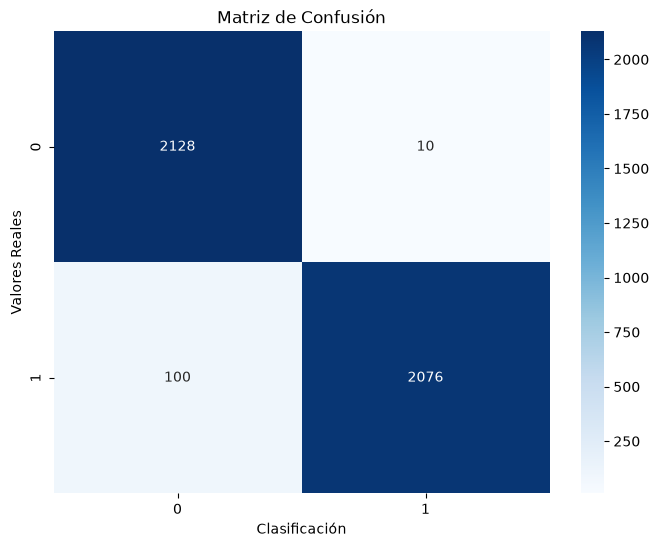

In [70]:
 # Undersampler results

cross_val_exactitud_rus = cross_val_score(mod_tree_class_rus, X_test_rus, y_test_rus, cv=kf)
print("Exactitud por cada fold:", cross_val_exactitud_rus)
print("Exactitud promedio:", np.mean(cross_val_exactitud_rus))
print("----------------------------------")

cross_val_f1_rus = cross_val_score(mod_tree_class_rus, X_test_rus, y_test_rus, cv=kf, scoring='f1')
print("F1 score por cada fold:", cross_val_f1_rus)
print("F1 score promedio:", np.mean(cross_val_f1_rus))
print("----------------------------------")

cross_val_precision_rus = cross_val_score(mod_tree_class_rus, X_test_rus, y_test_rus, cv=kf, scoring='precision')
print("Precisión por cada fold:", cross_val_precision_rus)
print("Precisión promedio:", np.mean(cross_val_precision_rus))
print("----------------------------------")

cross_val_recall_rus = cross_val_score(mod_tree_class_rus, X_test_rus, y_test_rus, cv=kf, scoring='recall')
print("Sensbilidad  por cada fold:", cross_val_recall_rus)
print("Sensbilidad  promedio:", np.mean(cross_val_recall_rus))
print("----------------------------------")

confusion = confusion_matrix(y_test_rus, y_pred_rus)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")

plt.xlabel('Clasificación')
plt.ylabel('Valores Reales')
plt.title('Matriz de Confusión')
plt.show()

### EN | DECISION TREE RESULTS INTERPRETATION
### ES | INTERPRETACIÓN DE LOS RESULTADOS DE ÁRBOL DE DECISIÓN

**Árbol de decisión sin balancear:** la exactitud de éste modelo fue buena, sin embargo el resto de métricas, fue inferior a los encontrados con
los modelos de regresión logística. Esto se debe a la tendencia del modelo a los falsos negativos, debido a la proporción baja entre fraudes y no fraudes.

**Árbol de decisión oversampler:** Tiene la exactitud más alta (alta tasa de clasificaciones correctas, sin importar el tipo de clasificación). Precisión y sensibilidad también tienen los valores más altos de entre todos los modelos evaluados, es el mejor modelo clasificando positivos.

Es muy probables que si el modelo arroja un positivo, sea correcto. Y es probable también que haya un número muy bajo de falsos negativos, esto es especialmente importante en éste tipo de casos donde capturar todos los positivos es crucial.
Por lo que su desempeño para clasificar fraudes en nuestro dataset es superior al resto de modelos.

**Árbol de decisión undersampler:** Éste modelo obtiene resultados muy semejantes a los obtenidos en la regresión logísitica con over y undersampler, las 4 métricas se mantienen balanceadas y arriba del 93%

---

EN | **English version:**

**Unbalanced decision tree:** this model's accuracy was good; however, the rest of the metrics were lower than those found with the logistic regression models. This is due to the model's tendency toward false negatives, caused by the low proportion of fraud vs. non-fraud cases.

**Oversampled decision tree:** has the highest accuracy (high rate of correct classifications, regardless of class). Precision and recall also have the highest values among all evaluated models, making it the best model at classifying positives.

It's very likely that if the model outputs a positive, it is correct. It's also likely that there is a very low number of false negatives, which is especially important in this type of case, where capturing all positives is crucial.
Therefore, its performance for classifying fraud in our dataset is superior to the rest of the models.

**Undersampled decision tree:** this model obtains results very similar to those obtained with logistic regression using over and undersampling; all 4 metrics remain balanced and above 93%.